# 01. 데이터 다운로드

HF `datasets`의 **`ksang/steamreviews`** (Kaggle Steam Reviews 미러, `review_text` + `review_score` 1/-1)에서
리뷰를 받아 원본 샘플을 `data/raw_sample.csv`로 저장하고 기초 EDA를 수행한다.

- 앞부분만 자르면 특정 게임(app_id 순 정렬)에 편중되므로 **셔플 후 샘플링**한다.
- 원본은 추천 82% : 비추천 18%로 불균형이 심해, 그대로 학습하면 모델이 다수 클래스(긍정)로
  붕괴한다. **클래스별로 5천 건씩 뽑아 50:50 균형 샘플 1만 건**을 만든다 (학습 시간 절충).
  (균형 test셋의 accuracy는 실제 서비스 분포에서의 성능과 다름을 보고서에 명시할 것)
- 정제·분할은 `02_preprocessing.ipynb`에서 진행한다.

In [1]:
import sys
from pathlib import Path

# 프로젝트 루트를 import 경로에 추가 (notebooks/ 하위에서 실행되므로)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from datasets import load_dataset, concatenate_datasets
from src.config import DATA_DIR, OUTPUT_DIR, RANDOM_SEED

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ID = "ksang/steamreviews"
LIMIT = 10000
PER_CLASS = LIMIT // 2

/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset(DATASET_ID, split="train")
print(f"전체 리뷰 수: {len(ds):,}")

# 클래스별 균형 샘플링: 추천/비추천 각 5천 건 (셔플 후 앞에서 선택)
pos = ds.filter(lambda b: [s == 1 for s in b["review_score"]], batched=True)
neg = ds.filter(lambda b: [s == -1 for s in b["review_score"]], batched=True)
print(f"추천: {len(pos):,} / 비추천: {len(neg):,}")

sample = concatenate_datasets([
    pos.shuffle(seed=RANDOM_SEED).select(range(PER_CLASS)),
    neg.shuffle(seed=RANDOM_SEED).select(range(PER_CLASS)),
]).shuffle(seed=RANDOM_SEED)
df = sample.to_pandas()
df.head(3)

Repo card metadata block was not found. Setting CardData to empty.


전체 리뷰 수: 6,417,106
추천: 5,260,420 / 비추천: 1,156,686


,app_id,app_name,review_text,review_score,review_votes
0,246090,Spacebase DF-9,The devs left the game to rot.,-1,0
1,231430,Company of Heroes 2,The game could have been good if it was not fo...,-1,0
2,238090,Sniper Elite 3,The Sniper Elite franchise has had a rocky sta...,1,1


## 결측치·노이즈 점검 — 무엇을 전처리해야 하는가

원본 샘플에서 컬럼별 결측치와 학습에 방해되는 노이즈 유형을 정량화한다.
여기서 확인된 항목이 `02_preprocessing.ipynb`의 정제 규칙 근거가 된다.
표는 `output/01_*.csv`, 그래프는 `output/01_*.png`로 저장한다.

| 점검 항목 | 대응 (02 노트북) |
|---|---|
| `review_text` 결측·빈 문자열 | 행 제거 |
| 중복 리뷰 | 중복 제거 |
| "Early Access Review" 보일러플레이트 | 접두 문구 제거 (Steam 자동 삽입 문구, 감성과 무관) |
| HTML 엔티티 (`&quot;` 등) | 원문 문자로 복원 (unescape) |
| BBCode 마크업 (`[h1]`, `[b]` 등) | 정규식 제거 |
| URL 포함 | 정규식 제거 |
| 3회 이상 반복 문자 (`sooooo`, `♥♥♥♥`) | 2회로 축약 |
| 영숫자 없음 (이모지·기호만) | 행 제거 (감성 신호 없음) |
| 3단어 미만 초단문 (`"gud"`, `"+"`) | 최소 길이 필터 |

In [3]:
import pandas as pd

# 컬럼별 결측치
na = df.isna().sum()
missing = pd.DataFrame({"결측 수": na, "비율": (na / len(df)).round(4)})
missing.to_csv(OUTPUT_DIR / "01_missing_values.csv", encoding="utf-8-sig")
print("컬럼별 결측치:")
display(missing)

컬럼별 결측치:


,결측 수,비율
app_id,0,0.0000
app_name,341,0.0341
review_text,12,0.0012
review_score,0,0.0000
review_votes,0,0.0000


/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_24474/1267178388.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "반복 문자 (3회+)": int(texts.str.contains(r"(.)\1{2,}", regex=True).sum()),


,리뷰 수,비율
결측/빈 문자열,12,0.0012
중복 리뷰,1734,0.1734
Early Access 보일러플레이트,1688,0.1688
HTML 엔티티,192,0.0192
BBCode 포함,9,0.0009
URL 포함,75,0.0075
반복 문자 (3회+),2617,0.2617
영숫자 없음 (기호만),40,0.0040
3단어 미만,221,0.0221


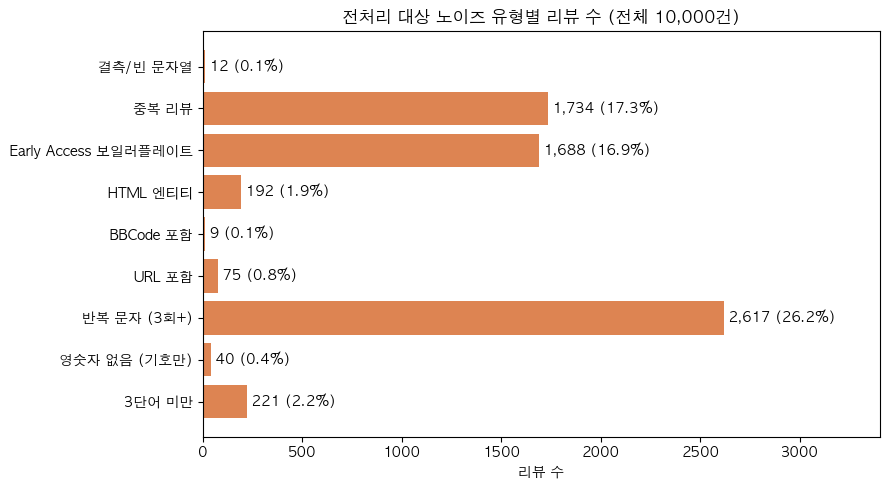

In [4]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# 전처리 대상 노이즈 유형별 리뷰 수
texts = df["review_text"].astype(str)
valid = df["review_text"].notna() & (texts.str.strip().str.len() > 0)

noise = pd.Series({
    "결측/빈 문자열": int((~valid).sum()),
    "중복 리뷰": int(texts[valid].duplicated().sum()),
    "Early Access 보일러플레이트": int(texts.str.match(r"^\s*Early Access Review", case=False).sum()),
    "HTML 엔티티": int(texts.str.contains(r"&(?:quot|amp|lt|gt|#\d+);", regex=True).sum()),
    "BBCode 포함": int(texts.str.contains(r"\[/?[a-zA-Z0-9*=]+\]", regex=True).sum()),
    "URL 포함": int(texts.str.contains(r"https?://|www\.", regex=True).sum()),
    "반복 문자 (3회+)": int(texts.str.contains(r"(.)\1{2,}", regex=True).sum()),
    "영숫자 없음 (기호만)": int((~texts.str.contains(r"[A-Za-z0-9]", regex=True)).sum()),
    "3단어 미만": int((texts.str.split().str.len() < 3).sum()),
})
noise_df = noise.to_frame("리뷰 수").assign(비율=(noise / len(df)).round(4))
noise_df.to_csv(OUTPUT_DIR / "01_noise_diagnosis_v2.csv", encoding="utf-8-sig")
display(noise_df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(noise.index[::-1], noise.values[::-1], color="#dd8452")
for i, v in enumerate(noise.values[::-1]):
    ax.text(v, i, f" {v:,} ({v / len(df):.1%})", va="center")
ax.set_title(f"전처리 대상 노이즈 유형별 리뷰 수 (전체 {len(df):,}건)")
ax.set_xlabel("리뷰 수")
ax.set_xlim(0, noise.max() * 1.3)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "01_noise_diagnosis_v2.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# 원본 샘플 저장 (전처리는 02 노트북에서)
DATA_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(DATA_DIR / "raw_sample.csv", index=False)
print(f"raw_sample.csv 저장: {len(df):,}건")
print(df["review_score"].value_counts(normalize=True).rename({1: "추천", -1: "비추천"}))

raw_sample.csv 저장: 10,000건
review_score
비추천    0.5
추천     0.5
Name: proportion, dtype: float64


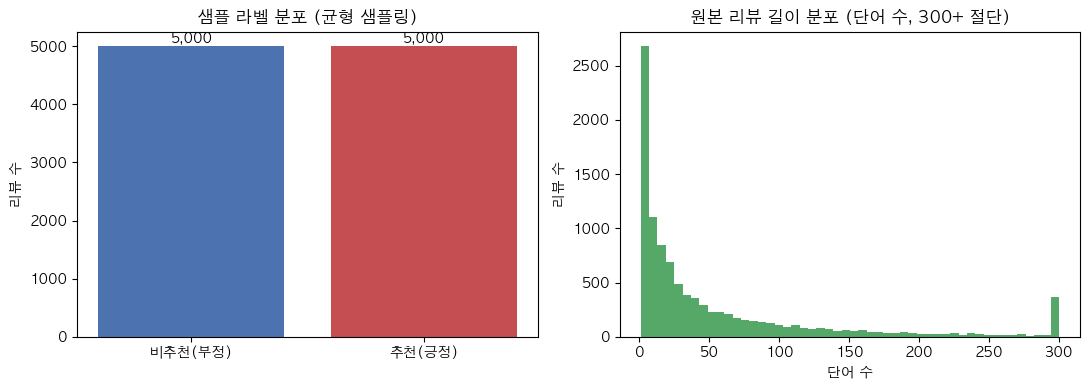

In [6]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

counts = df["review_score"].value_counts().rename({1: "추천(긍정)", -1: "비추천(부정)"})
ax1.bar(counts.index, counts.values, color=["#4c72b0", "#c44e52"])
ax1.set_title("샘플 라벨 분포 (균형 샘플링)")
ax1.set_ylabel("리뷰 수")
for i, v in enumerate(counts.values):
    ax1.text(i, v, f"{v:,}", ha="center", va="bottom")

lengths = df["review_text"].astype(str).str.split().str.len()
ax2.hist(lengths.clip(upper=300), bins=50, color="#55a868")
ax2.set_title("원본 리뷰 길이 분포 (단어 수, 300+ 절단)")
ax2.set_xlabel("단어 수")
ax2.set_ylabel("리뷰 수")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "01_raw_label_length_dist_v2.png", dpi=150, bbox_inches="tight")
plt.show()